In [77]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go


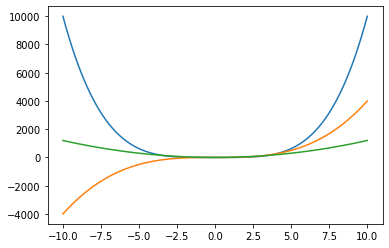

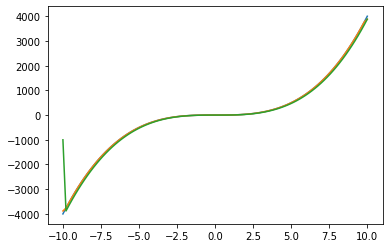

In [78]:
xs=np.linspace(-10,10,100)

f=np.power(xs,4)
fp=4*np.power(xs,3)
fpp=12*np.power(xs,2)

plt.plot(xs,f)
plt.plot(xs,fp)
plt.plot(xs,fpp)
plt.show()

plt.plot(xs,fp)
plt.plot(xs,np.gradient(f,xs))
plt.plot(xs,np.diff(f,prepend=0)/np.diff(xs,prepend=0))


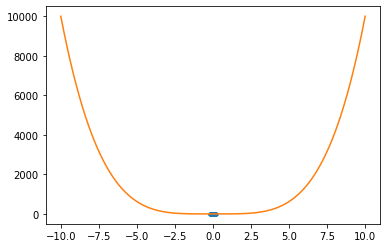

In [79]:
x=np.linspace(-10,10,100)
for i in range(10):
    x=x-4/12*np.power(x,3)/np.power(x,2)

plt.plot(x,np.power(x,4),'.')
plt.plot(xs,f)


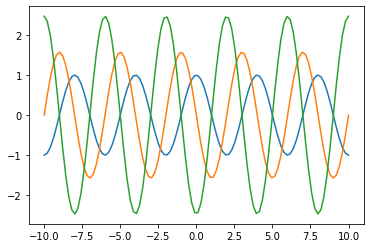

In [80]:
xs=np.linspace(-10,10,100)

O=0.5*np.pi


f=np.cos(O*xs)#np.power(xs,4)
fp=-O*np.sin(O*xs)
fpp=-np.power(O,2)*np.cos(O*xs)

plt.plot(xs,f)
plt.plot(xs,fp)
plt.plot(xs,fpp)



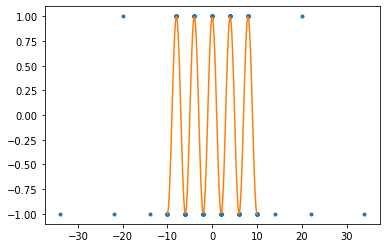

In [81]:
x=np.linspace(-10,10,100)
for i in range(10):
    x=x-(-O*np.sin(O*x))/(-np.power(O,2)*np.cos(O*x))

plt.plot(x,np.cos(O*x),'.')
plt.plot(xs,f)


In [82]:
def numericalEval(x,y,func,pts):
    dx=x[0,:]#np.mean(np.diff(x,axis=1))
    dy=y[:,0]#np.mean(np.diff(y,axis=0))

    #print(dx,dy)
    f=func(x,y)#.reshape([pts,pts])
    V=np.array([np.gradient(f,dx,axis=0),np.gradient(f,dy,axis=1)])
    C=np.array([[np.gradient(V[0,...],dx,axis=0),np.gradient(V[0,...],dy,axis=1)],[np.gradient(V[1,...],dx,axis=0),np.gradient(V[1,...],dy,axis=1)]])
    #C[np.where(C<1E-8)]=0
    C[np.where(np.abs(C)<1E-8)]=0

    # V=V.reshape([2,-1])
    # C=C.reshape([2,2,-1])
    # V=np.rollaxis(V,-1,0)
    # C=np.rollaxis(C,-1,0)
    return V,C

In [83]:
pts=100
rng=100
xi,yi=np.meshgrid(np.linspace(-rng,rng,pts),np.linspace(-rng,rng,pts))


#f=np.cos(a*np.pi*x)+np.sin(b*np.pi*y)

#fi=np.power(xi,4)*np.power(yi,4)
a=-100
func=lambda x,y:np.power(x,3)+np.power(y,3)-a*(np.power(x,2)+np.power(y,2))

fi=func(xi,yi)
fig = go.Figure(data=[go.Surface(
    x=xi.reshape((pts,pts)),
    y=yi.reshape((pts,pts)),
    z=fi.reshape((pts,pts)),
    #surfacecolor=np.ones((pts,pts)),
    colorscale='viridis',
    opacity=1,
    )])
fig.show()

Gx=np.diff(fi,axis=0)/np.diff(xi,axis=1).T

#G=np.gradient(fi,yi,xi)

V,C=numericalEval(xi,yi,func,pts)
Va=np.array([3*np.power(xi,2)-2*a*xi,3*np.power(yi,2)-2*a*yi])
Ca=np.array([[6*np.power(xi,1)-2*a,np.zeros_like(xi)],[np.zeros_like(yi),6*np.power(yi,1)-2*a]])

i=1

print(Gx[i,i])
print(V[...,i,i],Va[...,i,i])
print('\n')
CT=C[...,i,i]
print(CT)
CT[np.where(np.abs(CT)<1E-8)]=0
print(CT,Ca[...,i,i])



print('\n')
print(np.linalg.inv(C[...,i,i]),np.linalg.inv(Ca[...,i,i]))


8816.447301295917
[9208.24405673 9208.24405673] [9204.16284053 9204.16284053]


[[-287.87878788    0.        ]
 [   0.         -287.87878788]]
[[-287.87878788    0.        ]
 [   0.         -287.87878788]] [[-387.87878788    0.        ]
 [   0.         -387.87878788]]


[[-0.00347368 -0.        ]
 [-0.         -0.00347368]] [[-0.00257813 -0.        ]
 [-0.         -0.00257813]]


In [84]:
# pts=50
# rng=50
#x,y=np.meshgrid(np.linspace(-rng,rng,pts),np.linspace(-rng,rng,pts))
#xs=np.vstack([xi.flatten(),yi.flatten()])
xs=np.array([xi,yi])
for i in range(10):
    x=xs[0,:]
    y=xs[1,:]
    #V=4*np.array([np.power(x,3)*np.power(y,4),np.power(y,3)*np.power(x,4)])
    #V=4*np.array([np.power(x,3),np.power(y,3)])
    #V=3*np.array([np.power(x,2),np.power(y,2)])
    #V=np.array([3*np.power(x,2)-2*a*x,3*np.power(y,2)-2*a*y])

    #C=np.array([[12*np.power(x,2)*np.power(y,4),16*np.power(x*y,3)],[16*np.power(x*y,3),12*np.power(y,2)*np.power(x,4)]])
    #C=np.array([[12*np.power(x,2),np.zeros_like(x)],[np.zeros_like(y),12*np.power(y,2)]])
    #C=np.array([[6*np.power(x,1),np.zeros_like(x)],[np.zeros_like(y),6*np.power(y,1)]])
    #C=np.array([[6*np.power(x,1)-2*a,np.zeros_like(x)],[np.zeros_like(y),6*np.power(y,1)-2*a]])

    #V=np.rollaxis(V,-1,0)    
    #C=np.rollaxis(C,-1,0)
    V,C=numericalEval(x,y,func,pts)

    S=np.matmul(np.linalg.inv(C.T),V.T[...,None]).real
    S=np.squeeze(S).T
    xs=xs-S

x=xs[0,:]
y=xs[1,:]
#f=np.cos(np.pi/2*x*y)
#f=np.power(x,4)+np.power(y,4)
f=func(x,y)#np.power(x,3)+np.power(y,3)
# xi,yi=np.meshgrid(np.linspace(-2*np.max(x),2*np.max(x),pts),np.linspace(-2*np.max(y),2*np.max(y),pts))
# fi=func(xi,yi)
fig = go.Figure(data=[go.Surface(
    x=xi.reshape((pts,pts)),
    y=yi.reshape((pts,pts)),
    z=fi.reshape((pts,pts)),
#    surfacecolor=np.linalg.norm(V,axis=1).reshape((pts,pts)),
    colorscale='viridis',
    opacity=1,
    ),go.Scatter3d(
    x=(x).flatten(),
    y=(y).flatten(),
    z=(f).flatten(),
    mode='markers',
    )])
fig.show()
# plt.plot(x,np.power(xs[]),'.')
# plt.plot(xs,f)


LinAlgError: Singular matrix

In [ ]:
raise ValueError("Stop you've violated the law!!!")

ValueError: Stop you've violated the law!!!

In [ ]:
pts=100
rng=50
xi,yi=np.meshgrid(np.linspace(-rng,rng,pts),np.linspace(-rng,rng,pts))
xi=xi.flatten()
yi=yi.flatten()

a=np.pi/10
b=np.pi/20


#def numericalEval(func,x,y,pts):



func=lambda x,y: np.cos(a*x)+np.sin(b*y)
fi=func(xi,yi)

#f=np.power(x*y,4)
fig = go.Figure(data=[go.Surface(
    x=xi.reshape((pts,pts)),
    y=yi.reshape((pts,pts)),
    z=fi.reshape((pts,pts)),
    #surfacecolor=np.ones((pts,pts)),
    colorscale='viridis',
    opacity=1,
    )])
fig.show()

In [ ]:
pts=50
rng=50
xi,yi=np.meshgrid(np.linspace(-rng,rng,pts),np.linspace(-rng,rng,pts))
fi=func(xi,yi)
xs=np.vstack([xi.flatten(),yi.flatten()])
for i in range(100):
    x=xs[0,:]
    y=xs[1,:]
    V=np.array([-a*np.sin(a*x),b*np.cos(b*y)])
    V=np.rollaxis(V,-1,0)
    C=np.array([[-np.square(a)*np.cos(a*x),np.zeros_like(x)],[np.zeros_like(y),-np.square(b)*np.sin(b*y)]])
    C=np.rollaxis(C,-1,0)

    S=np.matmul(np.linalg.inv(C),V[...,None]).real
    S=np.squeeze(S).T
    xs=xs-2*S

x=xs[0,:]
y=xs[1,:]
#f=np.cos(np.pi/2*x*y)
#f=np.cos(a*np.pi*x)+np.sin(b*np.pi*y)
f=func(x,y)
#xi,yi=np.meshgrid(np.linspace(np.min(x),np.max(x),pts),np.linspace(np.min(y),np.max(y),pts))


#fi=np.cos(a*np.pi*xi)+np.sin(b*np.pi*yi)
fig = go.Figure(data=[go.Surface(
    x=xi.reshape((pts,pts)),
    y=yi.reshape((pts,pts)),
    z=fi.reshape((pts,pts)),
    #surfacecolor=np.ones((pts,pts)),
    colorscale='viridis',
    opacity=1,
    ),go.Scatter3d(
    x=(x),
    y=(y),
    z=(f),
    mode='markers',
    )])
fig.show()
# plt.plot(x,np.power(xs[]),'.')
# plt.plot(xs,f)


In [ ]:
pts=100
rng=50
xi,yi=np.meshgrid(np.linspace(-rng,rng,pts),np.linspace(-rng,rng,pts))
fi=func(xi,yi)
#xs=np.vstack([xi.flatten(),yi.flatten()])
xs=np.vstack([xi.flatten(),yi.flatten()])

for i in range(100):
    x=xs[0,:]
    y=xs[1,:]

    S=np.matmul(np.linalg.inv(C),V[...,None]).real
    S=np.squeeze(S).T
    xs=xs-1*S

x=xs[0,:]
y=xs[1,:]
#f=np.cos(np.pi/2*x*y)
#f=np.cos(a*np.pi*x)+np.sin(b*np.pi*y)
f=func(x,y)
#xi,yi=np.meshgrid(np.linspace(np.min(x),np.max(x),pts),np.linspace(np.min(y),np.max(y),pts))


#fi=np.cos(a*np.pi*xi)+np.sin(b*np.pi*yi)
fig = go.Figure(data=[go.Surface(
    x=xi.reshape((pts,pts)),
    y=yi.reshape((pts,pts)),
    z=fi.reshape((pts,pts)),
    #surfacecolor=np.ones((pts,pts)),
    colorscale='viridis',
    opacity=1,
    ),go.Scatter3d(
    x=(x),
    y=(y),
    z=(f),
    mode='markers',
    )])
fig.show()
# plt.plot(x,np.power(xs[]),'.')
# plt.plot(xs,f)


In [ ]:
pts=100
rng=50
x,y=np.meshgrid(np.linspace(-rng,rng,pts),np.linspace(-rng,rng,pts))

f=func(x,y)#.reshape((pts,pts))
V=np.array([np.gradient(f,axis=0),np.gradient(f,axis=1)])
C=np.array([[np.gradient(V[0,...],axis=0),np.gradient(V[0,...],axis=1)],[np.gradient(V[1,...],axis=0),np.gradient(V[1,...],axis=1)]])

#V=np.rollaxis(V,0,-1)
Va=np.array([-a*np.sin(a*x),b*np.cos(b*y)])
fig = go.Figure(data=[go.Surface(
    x=x.reshape((pts,pts)),
    y=y.reshape((pts,pts)),
    z=np.linalg.norm(V,axis=0),
    #surfacecolor=np.ones((pts,pts)),
    colorscale='viridis',
    opacity=1,
    ),go.Surface(
    x=x.reshape((pts,pts)),
    y=y.reshape((pts,pts)),
    z=np.linalg.norm(Va,axis=0),
    #surfacecolor=np.ones((pts,pts)),
    colorscale='tropic',
    opacity=1,
    )])
fig.show()
